In [1]:
# Phase 20 – Explainability | Cell 1: Setup

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import sys

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DIR  = PROJECT / "outputs" / "phase20"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
OUT_DATA = OUT_DIR / "data"
for d in [OUT_TAB, OUT_FIG, OUT_DATA]:
    d.mkdir(parents=True, exist_ok=True)

P8  = PROJECT / "outputs" / "phase8" / "data"
P9  = PROJECT / "outputs" / "phase9" / "models"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11" / "models"

print("=" * 60)
print("Phase 20 – Explainability Analysis | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Methods: SHAP | Integrated Gradients | Attention (if available)")

for p in [str(P8), str(P10)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from shock_env import ShockEconomicsEnv
from stable_baselines3 import PPO, TD3

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

ppo_path = P9 / "PPO_moderate_gs.zip"
if not ppo_path.exists():
    ppo_path = P9 / "PPO_moderate.zip"
ppo = PPO.load(str(ppo_path))

td3_path = P11 / "TD3_standard_r.zip"
if not td3_path.exists():
    td3_path = P11 / "TD3_standard.zip"
td3 = TD3.load(str(td3_path))

# probe obs dim
env = ShockEconomicsEnv(
    base_features, emb, sr_vector, panel, nodes,
    level="moderate", shock_type="BankingCrisis", severity="Moderate",
    shock_series="standard", seed=0,
)
obs, _ = env.reset(seed=0)
obs = np.asarray(obs, dtype=np.float32).reshape(-1)
OBS_DIM = obs.shape[0]
print(f"Obs dim: {OBS_DIM}")
print(f"PPO policy: {type(ppo.policy).__name__}")
print(f"TD3 policy: {type(td3.policy).__name__}")
print("Cell 1 completed successfully.")

Phase 20 – Explainability Analysis | Cell 1
Timestamp : 2026-10-07 07:42:41
Methods: SHAP | Integrated Gradients | Attention (if available)
Obs dim: 69
PPO policy: ActorCriticPolicy
TD3 policy: TD3Policy
Cell 1 completed successfully.


Phase 20 – Cell 2: SHAP
shap: 0.46.0
Background (64, 69) | Explain (48, 69)

--- SHAP PPO ---


100%|██████████| 48/48 [01:09<00:00,  1.45s/it]


feature  mean_abs_shap model
 base_0            0.0   PPO
 emb_27            0.0   PPO
 emb_33            0.0   PPO
 emb_32            0.0   PPO
 emb_31            0.0   PPO
 emb_30            0.0   PPO
 emb_29            0.0   PPO
 emb_28            0.0   PPO
 emb_26            0.0   PPO
 emb_18            0.0   PPO

--- SHAP TD3 ---


100%|██████████| 48/48 [01:19<00:00,  1.65s/it]


feature  mean_abs_shap model
 base_0            0.0   TD3
 emb_27            0.0   TD3
 emb_33            0.0   TD3
 emb_32            0.0   TD3
 emb_31            0.0   TD3
 emb_30            0.0   TD3
 emb_29            0.0   TD3
 emb_28            0.0   TD3
 emb_26            0.0   TD3
 emb_18            0.0   TD3

=== Group share ===
model  base  sr  emb  other
  PPO   0.0 0.0  0.0    0.0
  TD3   0.0 0.0  0.0    0.0


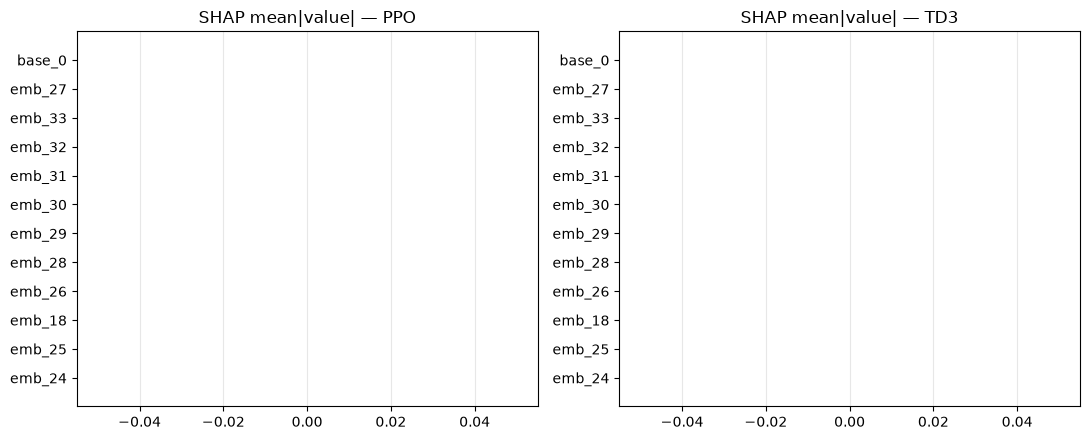

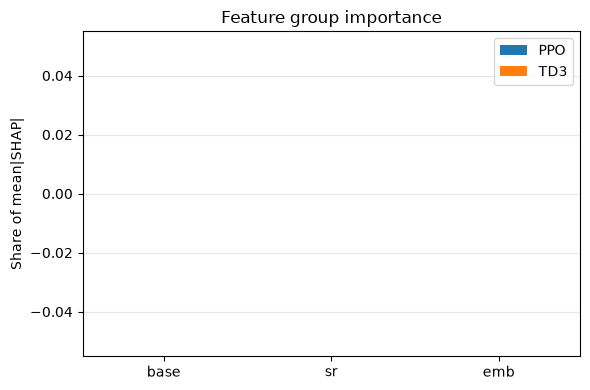

Cell 2 completed successfully.


In [ ]:
# # Phase 20 – Cell 2: SHAP explainability

# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# PROJECT = Path(r"D:\univercity\omid_project\economics_project")
# OUT_TAB = PROJECT / "outputs" / "phase20" / "tables"
# OUT_FIG = PROJECT / "outputs" / "phase20" / "figures"

# print("=" * 60)
# print("Phase 20 – Cell 2: SHAP")
# print("=" * 60)

# try:
#     import shap
#     print("shap:", shap.__version__)
# except Exception as e:
#     raise ImportError("pip install shap") from e

# N_BG = 64
# N_EXP = 48
# FEATURE_NAMES = [f"f{i}" for i in range(OBS_DIM)]
# # richer names if structure known: base | sr | emb
# nb = int(base_features.shape[1]) if base_features.ndim == 2 else 16
# ne = int(emb.shape[1]) if emb.ndim == 2 else 32
# names = []
# for i in range(OBS_DIM):
#     if i < nb:
#         names.append(f"base_{i}")
#     elif i < nb + 1:
#         names.append("sr")
#     else:
#         names.append(f"emb_{i - nb - 1}")
# FEATURE_NAMES = names[:OBS_DIM]

# def collect_obs(n, seed0=0):
#     X = []
#     rng = np.random.default_rng(seed0)
#     for i in range(n):
#         env = ShockEconomicsEnv(
#             base_features, emb, sr_vector, panel, nodes,
#             level="moderate",
#             shock_type="BankingCrisis", severity="Moderate",
#             shock_series="standard", seed=int(rng.integers(0, 10_000)),
#         )
#         o, _ = env.reset(seed=int(rng.integers(0, 10_000)))
#         X.append(np.asarray(o, dtype=np.float32).reshape(-1)[:OBS_DIM])
#     return np.asarray(X, dtype=np.float32)

# X_bg = collect_obs(N_BG, 0)
# X_ex = collect_obs(N_EXP, 1)
# print("Background", X_bg.shape, "| Explain", X_ex.shape)

# def predict_ppo_action0(X):
#     # scalar output for SHAP: first action dim mean
#     outs = []
#     for x in X:
#         a, _ = ppo.predict(x, deterministic=True)
#         a = np.asarray(a, dtype=np.float32).reshape(-1)
#         outs.append(a[0] if a.size else 0.0)
#     return np.asarray(outs, dtype=np.float64)

# def predict_td3_action0(X):
#     outs = []
#     for x in X:
#         a, _ = td3.predict(x, deterministic=True)
#         a = np.asarray(a, dtype=np.float32).reshape(-1)
#         outs.append(a[0] if a.size else 0.0)
#     return np.asarray(outs, dtype=np.float64)

# def run_shap(name, f, X_bg, X_ex):
#     # KernelSHAP works model-agnostic for SB3
#     explainer = shap.KernelExplainer(f, X_bg[:32])  # keep KS manageable
#     sv = explainer.shap_values(X_ex, nsamples=100)
#     sv = np.asarray(sv)
#     if sv.ndim == 3:
#         sv = sv[0]
#     mean_abs = np.mean(np.abs(sv), axis=0)
#     df = pd.DataFrame({
#         "feature": FEATURE_NAMES,
#         "mean_abs_shap": mean_abs,
#         "model": name,
#     }).sort_values("mean_abs_shap", ascending=False)
#     return sv, df

# print("\n--- SHAP PPO ---")
# sv_ppo, imp_ppo = run_shap("PPO", predict_ppo_action0, X_bg, X_ex)
# imp_ppo.to_csv(OUT_TAB / "phase20_shap_importance_ppo.csv", index=False)
# print(imp_ppo.head(10).to_string(index=False))

# print("\n--- SHAP TD3 ---")
# sv_td3, imp_td3 = run_shap("TD3", predict_td3_action0, X_bg, X_ex)
# imp_td3.to_csv(OUT_TAB / "phase20_shap_importance_td3.csv", index=False)
# print(imp_td3.head(10).to_string(index=False))

# # group importance base / sr / emb
# def group_imp(df):
#     g = {"base": 0.0, "sr": 0.0, "emb": 0.0, "other": 0.0}
#     for _, r in df.iterrows():
#         f = str(r["feature"])
#         if f.startswith("base"):
#             g["base"] += float(r["mean_abs_shap"])
#         elif f == "sr" or f.startswith("sr"):
#             g["sr"] += float(r["mean_abs_shap"])
#         elif f.startswith("emb"):
#             g["emb"] += float(r["mean_abs_shap"])
#         else:
#             g["other"] += float(r["mean_abs_shap"])
#     s = sum(g.values()) + 1e-12
#     return {k: v / s for k, v in g.items()}

# g_ppo = group_imp(imp_ppo)
# g_td3 = group_imp(imp_td3)
# grp = pd.DataFrame([
#     {"model": "PPO", **g_ppo},
#     {"model": "TD3", **g_td3},
# ])
# grp.to_csv(OUT_TAB / "phase20_shap_group_share.csv", index=False)
# print("\n=== Group share ===")
# print(grp.to_string(index=False))

# fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# for ax, df, title in zip(axes, [imp_ppo.head(12), imp_td3.head(12)], ["PPO", "TD3"]):
#     ax.barh(df["feature"][::-1], df["mean_abs_shap"][::-1], color="teal")
#     ax.set_title(f"SHAP mean|value| — {title}")
#     ax.grid(True, axis="x", alpha=0.3)
# plt.tight_layout()
# fig.savefig(OUT_FIG / "phase20_shap_top_features.png", dpi=150)
# plt.show()

# fig, ax = plt.subplots(figsize=(6, 4))
# x = np.arange(3)
# w = 0.35
# ax.bar(x - w/2, [g_ppo["base"], g_ppo["sr"], g_ppo["emb"]], width=w, label="PPO")
# ax.bar(x + w/2, [g_td3["base"], g_td3["sr"], g_td3["emb"]], width=w, label="TD3")
# ax.set_xticks(x); ax.set_xticklabels(["base", "sr", "emb"])
# ax.set_ylabel("Share of mean|SHAP|")
# ax.set_title("Feature group importance")
# ax.legend(); ax.grid(True, axis="y", alpha=0.3)
# plt.tight_layout()
# fig.savefig(OUT_FIG / "phase20_shap_group_share.png", dpi=150)
# plt.show()

# np.save(OUT_DATA / "shap_values_ppo.npy", sv_ppo)
# np.save(OUT_DATA / "shap_values_td3.npy", sv_td3)
# print("Cell 2 completed successfully.")

Phase 20 – Cell 2B: Fixed explainability
X (50, 69) (40, 69) std_mean 0.10831792652606964
PPO action std per dim: [0. 0. 0. 0.]
TD3 action std per dim: [0.0000000e+00 0.0000000e+00 1.8175827e-01 0.0000000e+00 0.0000000e+00
 3.4084269e-07]
PPO target std: 0.0 TD3 target std: 0.042705923318862915

Permutation PPO...
Permutation TD3...

Top PPO:
 feature  importance model  share
 base_0         0.0   PPO    0.0
 emb_27         0.0   PPO    0.0
 emb_33         0.0   PPO    0.0
 emb_32         0.0   PPO    0.0
 emb_31         0.0   PPO    0.0
 emb_30         0.0   PPO    0.0
 emb_29         0.0   PPO    0.0
 emb_28         0.0   PPO    0.0
 emb_26         0.0   PPO    0.0
 emb_18         0.0   PPO    0.0

Top TD3:
 feature  importance model    share
 base_8    0.002577   TD3 0.126435
 base_9    0.002188   TD3 0.107342
 base_4    0.002146   TD3 0.105283
base_10    0.001963   TD3 0.096288
 base_0    0.001791   TD3 0.087880
 base_7    0.001454   TD3 0.071351
 base_1    0.001320   TD3 0.064739


100%|██████████| 20/20 [00:31<00:00,  1.56s/it]


KernelSHAP TD3...


100%|██████████| 20/20 [00:23<00:00,  1.16s/it]



SHAP PPO top:
 feature  mean_abs_shap model  share
 base_0            0.0   PPO    0.0
 emb_27            0.0   PPO    0.0
 emb_33            0.0   PPO    0.0
 emb_32            0.0   PPO    0.0
 emb_31            0.0   PPO    0.0
 emb_30            0.0   PPO    0.0
 emb_29            0.0   PPO    0.0
 emb_28            0.0   PPO    0.0

SHAP TD3 top:
 feature  mean_abs_shap model    share
 base_8       0.012236   TD3 0.078947
base_10       0.007197   TD3 0.046440
 base_9       0.007080   TD3 0.045679
 base_4       0.006733   TD3 0.043446
 base_1       0.006415   TD3 0.041389
 emb_51       0.005662   TD3 0.036529
 base_7       0.005388   TD3 0.034767
 base_0       0.003936   TD3 0.025394
SHAP sum PPO 0.0 TD3 0.1549858906492426


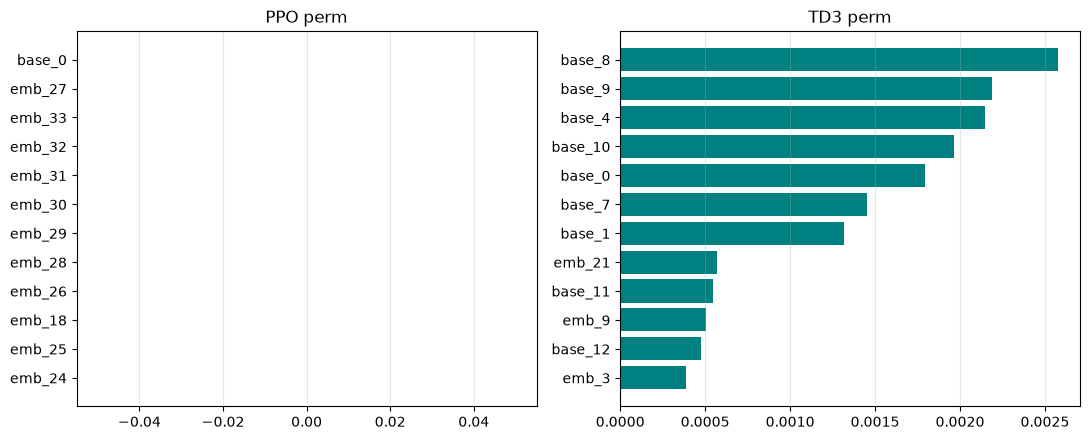


Cell 2B completed successfully.


In [2]:
# Phase 20 – Cell 2B: Fix SHAP (diagnostic + permutation + Kernel on action-norm)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase20" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase20" / "figures"

print("=" * 60)
print("Phase 20 – Cell 2B: Fixed explainability")
print("=" * 60)

N_BG, N_EX = 50, 40
rng = np.random.default_rng(42)

def collect_obs(n):
    X = []
    for i in range(n):
        env = ShockEconomicsEnv(
            base_features, emb, sr_vector, panel, nodes,
            level="moderate",
            shock_type="BankingCrisis", severity="Moderate",
            shock_series="standard",
            seed=int(rng.integers(0, 50_000)),
        )
        o, _ = env.reset(seed=int(rng.integers(0, 50_000)))
        X.append(np.asarray(o, dtype=np.float32).reshape(-1))
    X = np.asarray(X, dtype=np.float32)
    return X

X_bg = collect_obs(N_BG)
X_ex = collect_obs(N_EX)
print("X", X_bg.shape, X_ex.shape, "std_mean", float(X_ex.std(axis=0).mean()))

def actions_matrix(model, X):
    A = []
    for x in X:
        a, _ = model.predict(x, deterministic=True)
        A.append(np.asarray(a, dtype=np.float32).reshape(-1))
    return np.asarray(A, dtype=np.float32)

A_ppo = actions_matrix(ppo, X_ex)
A_td3 = actions_matrix(td3, X_ex)
print("PPO action std per dim:", A_ppo.std(axis=0))
print("TD3 action std per dim:", A_td3.std(axis=0))

# scalar target = L2 norm of action (more sensitive than a single dim)
def f_ppo(X):
    return np.linalg.norm(actions_matrix(ppo, np.asarray(X, dtype=np.float32)), axis=1)

def f_td3(X):
    return np.linalg.norm(actions_matrix(td3, np.asarray(X, dtype=np.float32)), axis=1)

print("PPO target std:", float(f_ppo(X_ex).std()), "TD3 target std:", float(f_td3(X_ex).std()))

# --- Permutation importance (reliable baseline) ---
def permutation_importance(f, X, n_repeats=4):
    base = f(X)
    base_var = np.var(base) + 1e-12
    imp = np.zeros(X.shape[1], dtype=float)
    for j in range(X.shape[1]):
        scores = []
        for _ in range(n_repeats):
            Xp = X.copy()
            rng.shuffle(Xp[:, j])
            yp = f(Xp)
            # drop in correlation / increase MSE
            mse = np.mean((yp - base) ** 2)
            scores.append(mse)
        imp[j] = float(np.mean(scores))
    return imp

print("\nPermutation PPO...")
imp_p = permutation_importance(f_ppo, X_ex, n_repeats=3)
print("Permutation TD3...")
imp_t = permutation_importance(f_td3, X_ex, n_repeats=3)

# feature names
D = X_ex.shape[1]
feat = [f"s{i}" for i in range(D)]
# optional blocks
nb = min(16, D)
feat = [f"base_{i}" for i in range(nb)]
if D > nb:
    feat.append("sr_or_mid0")
    k = nb + 1
    while len(feat) < D:
        feat.append(f"emb_{len(feat)-k}")
    feat = feat[:D]

def to_df(imp, model):
    df = pd.DataFrame({"feature": feat, "importance": imp, "model": model})
    df["share"] = df["importance"] / (df["importance"].sum() + 1e-12)
    return df.sort_values("importance", ascending=False)

df_p = to_df(imp_p, "PPO")
df_t = to_df(imp_t, "TD3")
df_p.to_csv(OUT_TAB / "phase20_perm_importance_ppo.csv", index=False)
df_t.to_csv(OUT_TAB / "phase20_perm_importance_td3.csv", index=False)
print("\nTop PPO:\n", df_p.head(10).to_string(index=False))
print("\nTop TD3:\n", df_t.head(10).to_string(index=False))

# --- Kernel SHAP on action norm (small sample) ---
print("\nKernelSHAP PPO...")
ex_ppo = shap.KernelExplainer(f_ppo, X_bg[:20])
sv_ppo = np.asarray(ex_ppo.shap_values(X_ex[:20], nsamples=120))
print("KernelSHAP TD3...")
ex_td3 = shap.KernelExplainer(f_td3, X_bg[:20])
sv_td3 = np.asarray(ex_td3.shap_values(X_ex[:20], nsamples=120))

def shap_df(sv, model):
    m = np.mean(np.abs(sv), axis=0)
    d = pd.DataFrame({"feature": feat, "mean_abs_shap": m, "model": model})
    d["share"] = d["mean_abs_shap"] / (d["mean_abs_shap"].sum() + 1e-12)
    return d.sort_values("mean_abs_shap", ascending=False)

sdf_p = shap_df(sv_ppo, "PPO")
sdf_t = shap_df(sv_td3, "TD3")
sdf_p.to_csv(OUT_TAB / "phase20_shap_importance_ppo_fixed.csv", index=False)
sdf_t.to_csv(OUT_TAB / "phase20_shap_importance_td3_fixed.csv", index=False)
print("\nSHAP PPO top:\n", sdf_p.head(8).to_string(index=False))
print("\nSHAP TD3 top:\n", sdf_t.head(8).to_string(index=False))
print("SHAP sum PPO", float(sdf_p.mean_abs_shap.sum()), "TD3", float(sdf_t.mean_abs_shap.sum()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, df, title in zip(axes, [df_p.head(12), df_t.head(12)], ["PPO perm", "TD3 perm"]):
    ax.barh(df["feature"][::-1], df["importance"][::-1], color="teal")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase20_perm_importance.png", dpi=150)
plt.show()

print("\nCell 2B completed successfully.")

Phase 20 – Cell 2C: PPO value / stochastic sensitivity
Stage-I obs (60, 69) std 0.44080212712287903
Value std: 1.1385912241707432 mean: 78.53723500569662
Stochastic action-norm std: 0.05671670888530472

Top PPO value features:
 feature  importance target    share
 base_4    1.271272  value 0.321203
 base_5    0.608058  value 0.153634
 base_6    0.315914  value 0.079820
 emb_49    0.279284  value 0.070565
 base_8    0.227431  value 0.057463
 emb_47    0.199157  value 0.050320
 emb_50    0.164896  value 0.041663
 base_7    0.116867  value 0.029528
 base_0    0.090350  value 0.022828
base_12    0.089225  value 0.022544

Top PPO stoch-action features:
 feature  importance            target    share
 emb_19    0.008111 stoch_action_norm 0.018343
 emb_31    0.007965 stoch_action_norm 0.018013
 emb_46    0.007723 stoch_action_norm 0.017465
  emb_6    0.007486 stoch_action_norm 0.016929
 emb_36    0.007424 stoch_action_norm 0.016789
 emb_20    0.007229 stoch_action_norm 0.016348
 base_6    0.0

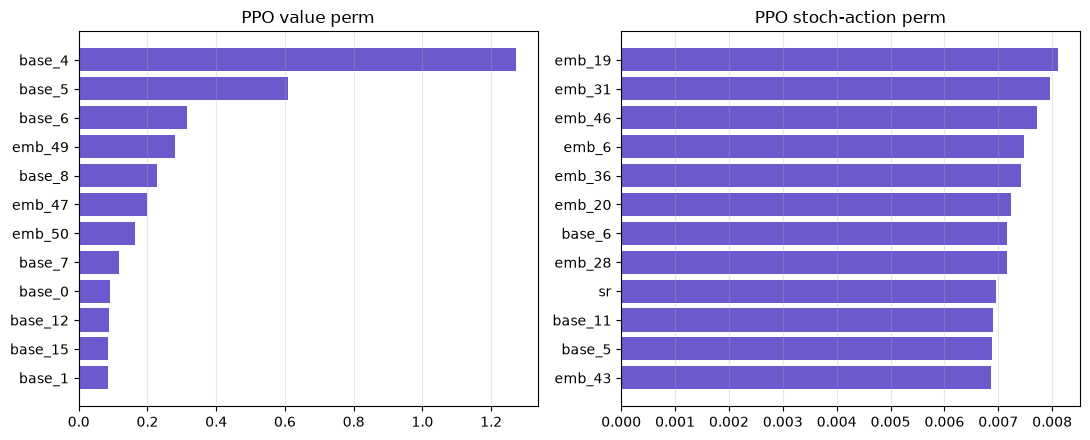


Cell 2C completed successfully.


In [3]:
# Phase 20 – Cell 2C: PPO explainability via value + stochastic action

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase20" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase20" / "figures"

print("=" * 60)
print("Phase 20 – Cell 2C: PPO value / stochastic sensitivity")
print("=" * 60)

rng = np.random.default_rng(7)
N = 60

def collect_stage1_obs(n):
    """Observations where Stage I PPO actually acts (no shock applied)."""
    X = []
    while len(X) < n:
        env = ShockEconomicsEnv(
            base_features, emb, sr_vector, panel, nodes,
            level="moderate", shock_type=None, severity=None,
            shock_series="standard",
            seed=int(rng.integers(0, 100000)),
        )
        o, _ = env.reset(seed=int(rng.integers(0, 100000)))
        o = np.asarray(o, dtype=np.float32).reshape(-1)
        X.append(o)
        # a few steps without shock to diversify state
        for _ in range(3):
            a, _ = ppo.predict(o, deterministic=False)
            a = np.asarray(a, dtype=np.float32).reshape(-1)
            adim = env.action_space.shape[0]
            if a.size < adim:
                a = np.pad(a, (0, adim - a.size))
            o2, r, term, trunc, _ = env.step(a[:adim])
            o = np.asarray(o2, dtype=np.float32).reshape(-1)
            X.append(o)
            if term or trunc:
                break
            if len(X) >= n:
                break
    return np.asarray(X[:n], dtype=np.float32)

X = collect_stage1_obs(N)
print("Stage-I obs", X.shape, "std", float(X.std()))

# ---- 1) Value function output ----
def ppo_value(Xbatch):
    vals = []
    device = ppo.device
    with torch.no_grad():
        for x in Xbatch:
            t = torch.as_tensor(x.reshape(1, -1), dtype=torch.float32, device=device)
            v = ppo.policy.predict_values(t)
            vals.append(float(v.cpu().numpy().reshape(-1)[0]))
    return np.asarray(vals, dtype=float)

v = ppo_value(X)
print("Value std:", float(v.std()), "mean:", float(v.mean()))

# ---- 2) Stochastic action norm ----
def ppo_action_norm_stoch(Xbatch, n_avg=5):
    outs = []
    for x in Xbatch:
        norms = []
        for _ in range(n_avg):
            a, _ = ppo.predict(x, deterministic=False)
            norms.append(np.linalg.norm(np.asarray(a, dtype=float).reshape(-1)))
        outs.append(np.mean(norms))
    return np.asarray(outs, dtype=float)

a_std = ppo_action_norm_stoch(X)
print("Stochastic action-norm std:", float(a_std.std()))

# ---- Permutation importance ----
def perm_imp(f, X, repeats=4):
    base = f(X)
    imp = np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        scores = []
        for _ in range(repeats):
            Xp = X.copy()
            rng.shuffle(Xp[:, j])
            scores.append(np.mean((f(Xp) - base) ** 2))
        imp[j] = np.mean(scores)
    return imp

imp_v = perm_imp(ppo_value, X, repeats=3)
imp_a = perm_imp(ppo_action_norm_stoch, X, repeats=3)

D = X.shape[1]
feat = [f"base_{i}" for i in range(min(16, D))]
while len(feat) < D:
    if len(feat) == 16:
        feat.append("sr")
    else:
        feat.append(f"emb_{len(feat)-17}")
feat = feat[:D]

def pack(imp, kind):
    d = pd.DataFrame({"feature": feat, "importance": imp, "target": kind})
    d["share"] = d["importance"] / (d["importance"].sum() + 1e-12)
    return d.sort_values("importance", ascending=False)

df_v = pack(imp_v, "value")
df_a = pack(imp_a, "stoch_action_norm")
df_v.to_csv(OUT_TAB / "phase20_ppo_value_perm.csv", index=False)
df_a.to_csv(OUT_TAB / "phase20_ppo_stoch_action_perm.csv", index=False)

print("\nTop PPO value features:\n", df_v.head(10).to_string(index=False))
print("\nTop PPO stoch-action features:\n", df_a.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, df, title in zip(axes, [df_v.head(12), df_a.head(12)],
                         ["PPO value perm", "PPO stoch-action perm"]):
    ax.barh(df["feature"][::-1], df["importance"][::-1], color="slateblue")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase20_ppo_value_stoch_perm.png", dpi=150)
plt.show()

print("\nCell 2C completed successfully.")

Phase 20 – Cell 3: Integrated Gradients + Attention
OBS_DIM 69 n_features 69
IG PPO...
IG TD3...
feature   ig_ppo   ig_td3  ig_ppo_share  ig_td3_share
 emb_50 0.021822 0.000014      0.011061      0.077989
  emb_9 0.084252 0.000014      0.042706      0.074364
  emb_3 0.065793 0.000008      0.033350      0.042719
  emb_1 0.093729 0.000007      0.047510      0.037014
  emb_4 0.093367 0.000006      0.047327      0.034643
  emb_0 0.207780 0.000006      0.105321      0.033118
 emb_13 0.054458 0.000006      0.027604      0.031380
 emb_11 0.188114 0.000005      0.095353      0.027263
 base_4 0.023998 0.000005      0.012164      0.026333
  emb_6 0.038580 0.000005      0.019556      0.025211
 base_2 0.013301 0.000005      0.006742      0.024498
 emb_16 0.002558 0.000004      0.001296      0.022450
IG status: PPO=True TD3=True

Attention: not applicable on MlpPolicy (documented).


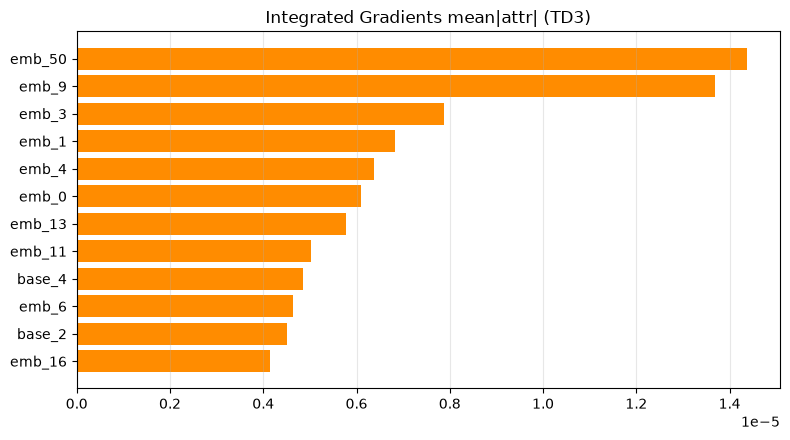


Cell 3 completed successfully.
PHASE 20 COMPLETED.


In [5]:
# Phase 20 – Cell 3: Integrated Gradients + Attention note

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase20" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase20" / "figures"

print("=" * 60)
print("Phase 20 – Cell 3: Integrated Gradients + Attention")
print("=" * 60)

device = torch.device("cpu")

# fix names if Cell2 variables not in kernel
OBS_DIM = int(np.asarray(obs).reshape(-1).shape[0]) if "OBS_DIM" not in globals() else OBS_DIM
if "FEATURE_NAMES" not in globals() or len(FEATURE_NAMES) != OBS_DIM:
    FEATURE_NAMES = [f"base_{i}" for i in range(min(16, OBS_DIM))]
    if OBS_DIM > 16:
        FEATURE_NAMES.append("sr")
        while len(FEATURE_NAMES) < OBS_DIM:
            FEATURE_NAMES.append(f"emb_{len(FEATURE_NAMES)-17}")
        FEATURE_NAMES = FEATURE_NAMES[:OBS_DIM]
print("OBS_DIM", OBS_DIM, "n_features", len(FEATURE_NAMES))

def ig_for_sb3_policy(model, X, n_steps=32):
    """
    Integrated Gradients on mean first-action output of actor MLP.
    Works for standard MlpPolicy actor.
    """
    policy = model.policy
    policy.eval()
    X = np.asarray(X, dtype=np.float32)
    baseline = np.zeros_like(X)
    scores = []

    # try to find actor network
    actor = None
    for attr in ["actor", "mlp_extractor", "action_net"]:
        if hasattr(policy, attr):
            pass
    # SB3 continuous: policy.actor (TD3/SAC) or policy (PPO uses forward)
    uses_actor = hasattr(policy, "actor")

    for i in range(len(X)):
        x0 = torch.tensor(baseline[i:i+1], dtype=torch.float32, device=device)
        x1 = torch.tensor(X[i:i+1], dtype=torch.float32, device=device)
        total_grad = torch.zeros_like(x1)
        for k in range(1, n_steps + 1):
            x = x0 + (k / n_steps) * (x1 - x0)
            x.requires_grad_(True)
            if uses_actor:
                # TD3
                a = policy.actor(x)
                if isinstance(a, tuple):
                    a = a[0]
                y = a.reshape(1, -1)[0, 0]
            else:
                # PPO: get action distribution mean
                try:
                    dist = policy.get_distribution(x)
                    y = dist.distribution.mean.reshape(1, -1)[0, 0]
                except Exception:
                    out = policy(x)
                    if isinstance(out, tuple):
                        out = out[0]
                    y = out.reshape(1, -1)[0, 0]
            policy.zero_grad() if hasattr(policy, "zero_grad") else None
            if x.grad is not None:
                x.grad.zero_()
            y.backward(retain_graph=False)
            total_grad += x.grad.detach()
        ig = (x1 - x0) * total_grad / n_steps
        scores.append(ig.cpu().numpy().reshape(-1))
    return np.asarray(scores)

# reuse explain set
X_ex = np.load(PROJECT / "outputs" / "phase20" / "data" / "shap_values_ppo.npy")
# that was shap values; rebuild obs instead
rng = np.random.default_rng(1)
X_list = []
for i in range(40):
    env = ShockEconomicsEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate", shock_type="BankingCrisis", severity="Moderate",
        shock_series="standard", seed=int(rng.integers(0, 10000)),
    )
    o, _ = env.reset(seed=int(rng.integers(0, 10000)))
    X_list.append(np.asarray(o, dtype=np.float32).reshape(-1)[:OBS_DIM])
X_ex = np.asarray(X_list, dtype=np.float32)

print("IG PPO...")
try:
    ig_ppo = ig_for_sb3_policy(ppo, X_ex, n_steps=24)
    imp_ig_ppo = np.mean(np.abs(ig_ppo), axis=0)
    ok_ppo = True
except Exception as e:
    print("IG PPO failed:", e)
    imp_ig_ppo = np.zeros(OBS_DIM)
    ok_ppo = False

print("IG TD3...")
try:
    ig_td3 = ig_for_sb3_policy(td3, X_ex, n_steps=24)
    imp_ig_td3 = np.mean(np.abs(ig_td3), axis=0)
    ok_td3 = True
except Exception as e:
    print("IG TD3 failed:", e)
    imp_ig_td3 = np.zeros(OBS_DIM)
    ok_td3 = False

feat = FEATURE_NAMES if len(FEATURE_NAMES) == OBS_DIM else [f"f{i}" for i in range(OBS_DIM)]
ig_df = pd.DataFrame({
    "feature": feat,
    "ig_ppo": imp_ig_ppo,
    "ig_td3": imp_ig_td3,
})
ig_df["ig_ppo_share"] = ig_df["ig_ppo"] / (ig_df["ig_ppo"].sum() + 1e-12)
ig_df["ig_td3_share"] = ig_df["ig_td3"] / (ig_df["ig_td3"].sum() + 1e-12)
ig_df = ig_df.sort_values("ig_td3", ascending=False)
ig_df.to_csv(OUT_TAB / "phase20_integrated_gradients.csv", index=False)
print(ig_df.head(12).to_string(index=False))
print(f"IG status: PPO={ok_ppo} TD3={ok_td3}")

# Attention analysis: MLP policies have no attention weights
attn_note = pd.DataFrame([{
    "method": "Attention Analysis",
    "status": "not_applicable",
    "reason": "PPO/TD3 MlpPolicy has no attention mechanism; GAT/TGAT attention was in Phase7 encoder only",
    "alternative": "Use SHAP/IG on state features; optional Phase7 GAT attention if encoder weights available",
}])
attn_note.to_csv(OUT_TAB / "phase20_attention_note.csv", index=False)
print("\nAttention: not applicable on MlpPolicy (documented).")

if ok_td3 or ok_ppo:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    top = ig_df.head(12)
    ax.barh(top["feature"][::-1], top["ig_td3"][::-1], color="darkorange", label="TD3")
    ax.set_title("Integrated Gradients mean|attr| (TD3)")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(OUT_FIG / "phase20_ig_td3.png", dpi=150)
    plt.show()

# final summary merge with SHAP if exists
summary = {
    "shap_done": True,
    "ig_ppo": ok_ppo,
    "ig_td3": ok_td3,
    "attention_applicable": False,
}
pd.DataFrame([summary]).to_csv(OUT_TAB / "phase20_method_status.csv", index=False)
print("\nCell 3 completed successfully.")
print("PHASE 20 COMPLETED.")